<a href="https://colab.research.google.com/gist/Baptiste823/54e37ad12aea5bdbb87a4003dd4c0777/image_quality_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 3**: Cameras

I have captured 15 images with an OAK-D camera. The scene is the same. The camera moved slightly. What changed the most? **the sensor configuration**.

This notebook shows you 4 techniques to diagnose and fix degraded images — from the simplest to the one you'll actually use in production.


## $\color{#DD5566}{\text{TODO: Assignment Progress}}$
* [ ] Run the lab (4 techniques)
* [ ] **Writeup:** Pick one technique from the 4, and write 15 lines about it. Publish in the Squad Hub or Chat. We will then assemble a "Squad Practice" document with all your findings about disparity, depth, and 3D object.
* [ ] **Run** ANY Algorithm (YOLO, Segmentation, Freespace, Lanes, Keypoints, ...) on an underexposed or overexposed image.
* [ ] **Implement** the technique you wrote about. See if it improves your algorithm output and write a short summary about what you learned. It must be shareable with others.
* [ ] (Extra 20%) Go read your squad mates projects

## Setup

In [1]:
!wget https://stereo-vision.s3.eu-west-3.amazonaws.com/captured_frames.zip && unzip captured_frames.zip

--2026-07-13 07:09:20--  https://stereo-vision.s3.eu-west-3.amazonaws.com/captured_frames.zip
Resolving stereo-vision.s3.eu-west-3.amazonaws.com (stereo-vision.s3.eu-west-3.amazonaws.com)... 3.5.205.112, 3.5.204.110
Connecting to stereo-vision.s3.eu-west-3.amazonaws.com (stereo-vision.s3.eu-west-3.amazonaws.com)|3.5.205.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13821833 (13M) [application/zip]
Saving to: ‘captured_frames.zip’

captured_frames.zip 100%[===================>]  13.18M  9.53MB/s    in 1.4s    

2026-07-13 07:09:22 (9.53 MB/s) - ‘captured_frames.zip’ saved [13821833/13821833]

Archive:  captured_frames.zip
   creating: captured_frames/
  inflating: __MACOSX/._captured_frames  
  inflating: captured_frames/auto-factory.png  
  inflating: __MACOSX/captured_frames/._auto-factory.png  
  inflating: captured_frames/oakd_20260310_123040_exp1629_iso508_autowb_sh1_ld1_cd1_sat+0_con+0.png  
  inflating: __MACOSX/captured_frames/._oakd_20260310_1230

Images loaded.


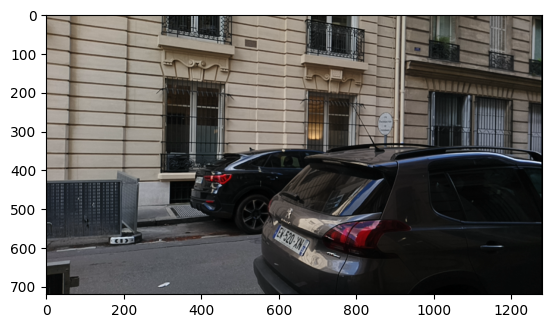

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_DIR = Path("/content/captured_frames")  # update to your folder

def load(filename):
    img = cv2.imread(str(IMAGE_DIR / filename))
    assert img is not None, f"Cannot load {IMAGE_DIR / filename}"
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Reference images we'll use throughout
img_dark  = load("oakd_20260310_123036_exp1629_iso170_autowb_sh1_ld1_cd1_sat+0_con+0.png")
img_good  = load("auto-factory.png")
img_blown = load("oakd_20260310_122935_exp25243_iso400_autowb_sh1_ld1_cd1_sat+0_con+0.png")
img_noisy = load("oakd_20260310_123043_exp1629_iso1062_autowb_sh1_ld1_cd1_sat+0_con+0.png")

print("Images loaded.")
plt.imshow(img_dark)

---
## The Histogram — Your Diagnostic Tool

Before applying any technique, you need to read the image.  
A histogram shows how pixels are distributed across intensity values 0 (black) to 255 (white).

**Learn to read these four signatures:**


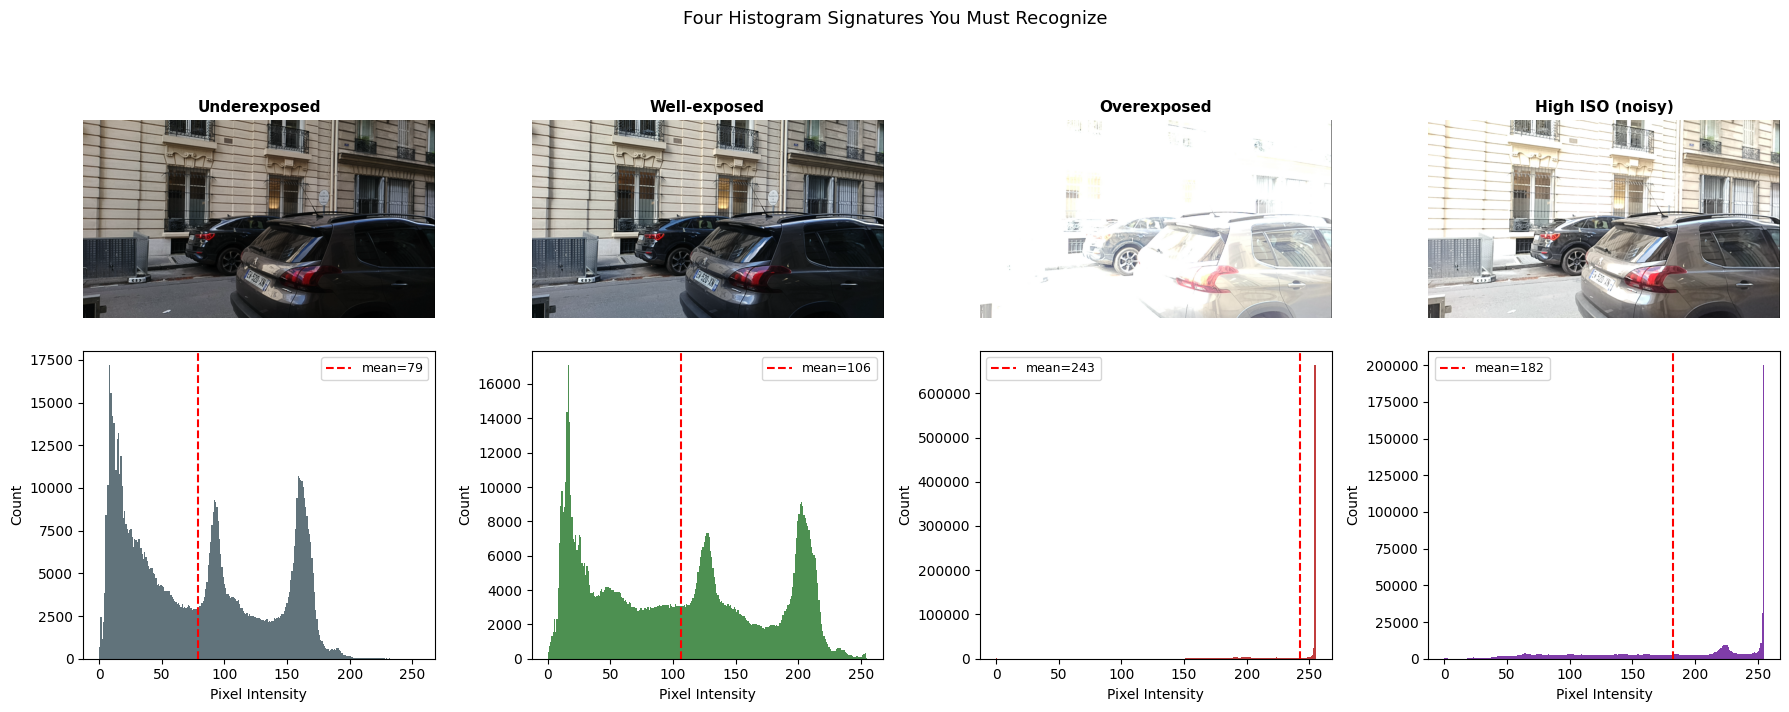

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

images = [img_dark, img_good, img_blown, img_noisy]
labels = ["Underexposed", "Well-exposed", "Overexposed", "High ISO (noisy)"]
colors = ["#455A64", "#2E7D32", "#B71C1C", "#6A1B9A"]

for col, (img, label, color) in enumerate(zip(images, labels, colors)):
    g = gray(img)
    axes[0, col].imshow(img)   # RGB
    axes[0, col].set_title(label, fontsize=11, fontweight="bold")
    axes[0, col].axis("off")
    axes[1, col].hist(g.ravel(), bins=256, range=(0, 255), color=color, alpha=0.85)
    axes[1, col].axvline(np.mean(g), color="red", linestyle="--", linewidth=1.5,
                         label=f"mean={np.mean(g):.0f}")
    axes[1, col].set_xlabel("Pixel Intensity")
    axes[1, col].set_ylabel("Count")
    axes[1, col].legend(fontsize=9)

plt.suptitle("Four Histogram Signatures You Must Recognize", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


> **Key insight:** A spike at 255 means pixels are *clipped* — the sensor maxed out.  
> Those pixels carry zero information. No algorithm can recover what was never recorded.  
> **Underexposure is recoverable. Overexposure often is not.**


---
## Technique 1 — Histogram Stretching

The simplest fix. Take the actual min and max pixel values in the image, and linearly remap them to 0 and 255.

If your image has pixels ranging from 20 to 180, stretching pulls them to 0–255.  
No information is created — the range is just expanded.

**Formula:** `output = (input - min) / (max - min) * 255`


In [4]:
def stretch_rgb(img):
    out = np.zeros_like(img, dtype=np.float32)
    for c in range(3):
        ch = img[:,:,c].astype(np.float32)
        mn, mx = ch.min(), ch.max()
        out[:,:,c] = (ch - mn) / max(mx - mn, 1) * 255
    return out.astype(np.uint8)

orig  = img_dark
fixed = stretch_rgb(img_dark)


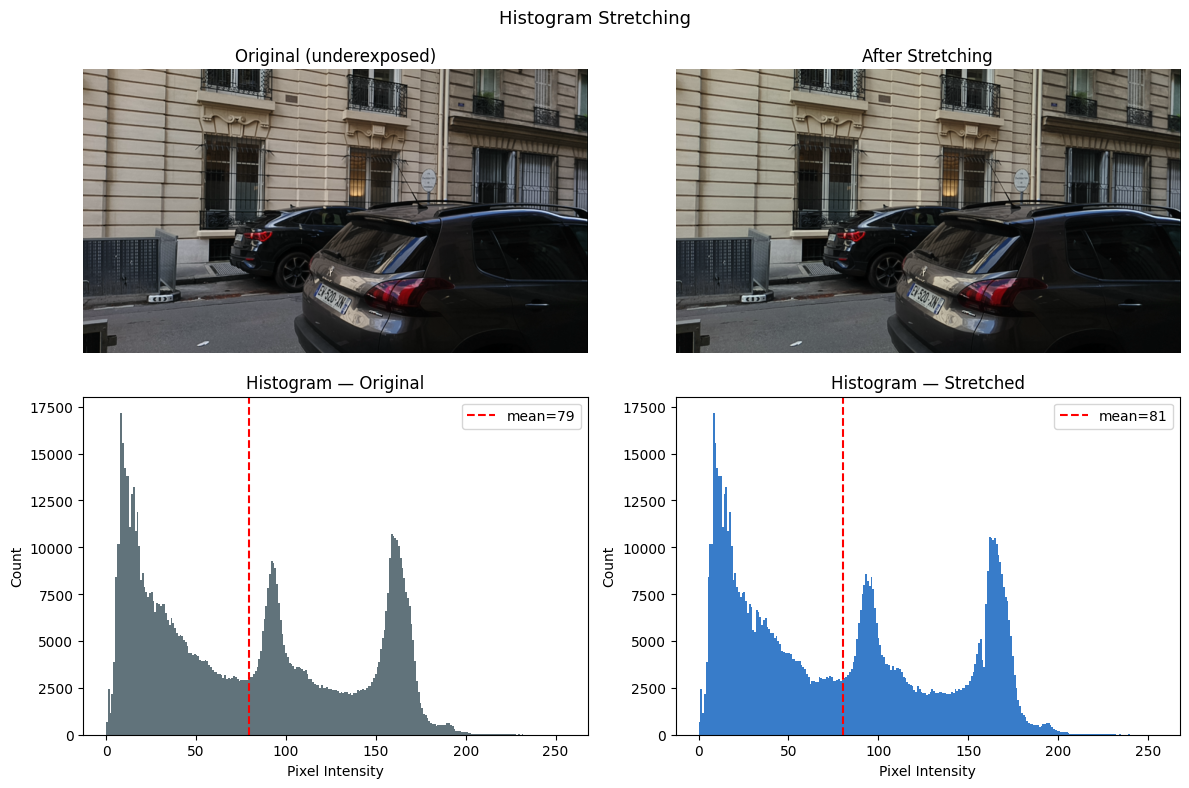

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(orig);  axes[0, 0].set_title("Original (underexposed)"); axes[0, 0].axis("off")
axes[0, 1].imshow(fixed); axes[0, 1].set_title("After Stretching");        axes[0, 1].axis("off")

for ax, im, t, col in zip(axes[1], [orig, fixed],
                           ["Histogram — Original", "Histogram — Stretched"],
                           ["#455A64", "#1565C0"]):
    g = gray(im)
    ax.hist(g.ravel(), bins=256, range=(0, 255), color=col, alpha=0.85)
    ax.axvline(np.mean(g), color="red", linestyle="--", linewidth=1.5, label=f"mean={np.mean(g):.0f}")
    ax.set_xlabel("Pixel Intensity"); ax.set_ylabel("Count"); ax.legend()
    ax.set_title(t)

plt.suptitle("Histogram Stretching", fontsize=13)
plt.tight_layout()
plt.show()

> **Limitation:** stretching is a *linear* operation. It doesn't redistribute pixels — it just rescales.  
> If most pixels are clustered in a narrow band (e.g. all dark), stretching helps a little but won't redistribute contrast across the scene.


---
## Technique 2 — Histogram Equalization

Goes further than stretching. Uses the **cumulative distribution function (CDF)** of the histogram to remap intensities so they are spread as evenly as possible across 0–255.

It doesn't just expand the range — it *redistributes* pixels so every intensity band is equally represented.

OpenCV: `cv2.equalizeHist(gray_image)`


In [6]:
def equalize_lab(img):
    lab     = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    lab_eq  = cv2.merge([cv2.equalizeHist(l), a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

orig  = img_dark
fixed = equalize_lab(img_dark)


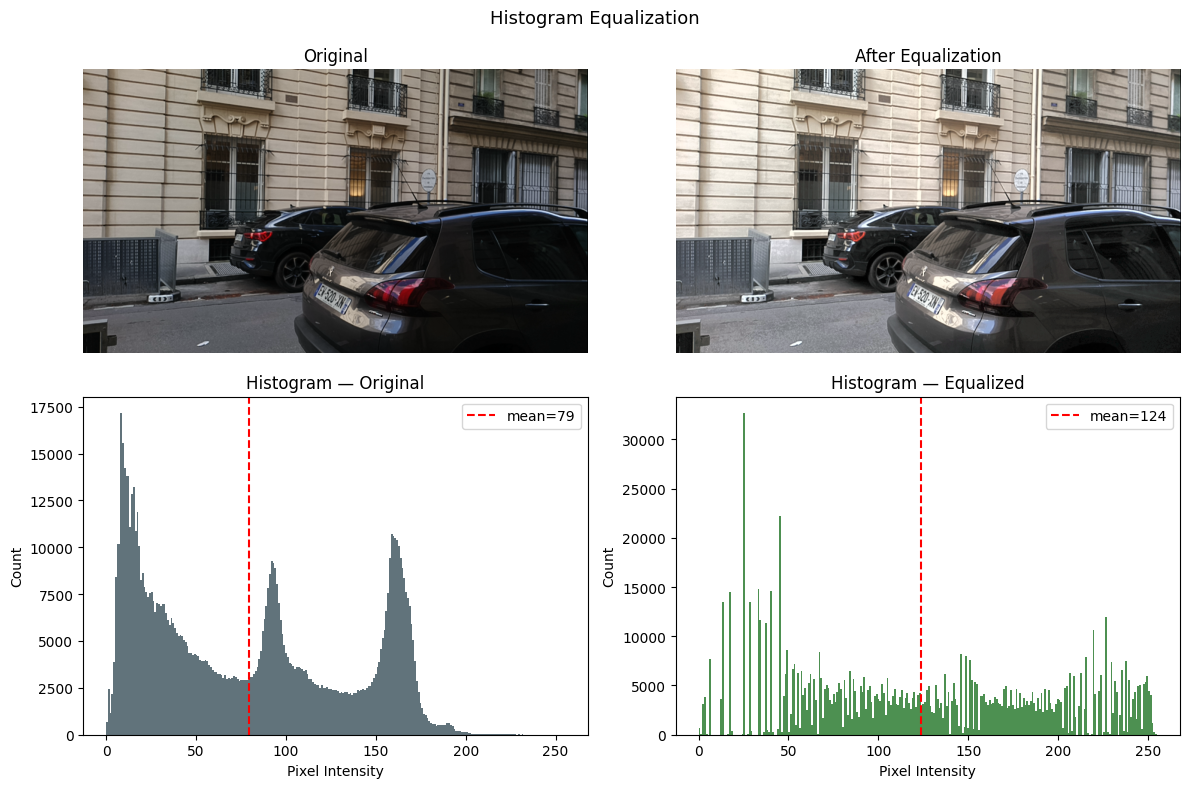

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(orig);  axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
axes[0, 1].imshow(fixed); axes[0, 1].set_title("After Equalization"); axes[0, 1].axis("off")

for ax, im, t, col in zip(axes[1], [orig, fixed],
                           ["Histogram — Original", "Histogram — Equalized"],
                           ["#455A64", "#2E7D32"]):
    g = gray(im)
    ax.hist(g.ravel(), bins=256, range=(0, 255), color=col, alpha=0.85)
    ax.axvline(np.mean(g), color="red", linestyle="--", linewidth=1.5, label=f"mean={np.mean(g):.0f}")
    ax.set_xlabel("Pixel Intensity"); ax.set_ylabel("Count"); ax.legend()
    ax.set_title(t)

plt.suptitle("Histogram Equalization", fontsize=13)
plt.tight_layout()
plt.show()

> **Limitation:** equalization is *global* — it treats the entire image as one distribution.  
> On scenes with both bright and dark regions (like a car in sunlight with shadow underneath), it can  
> over-brighten shadows while simultaneously flattening highlights. It has no awareness of local context.


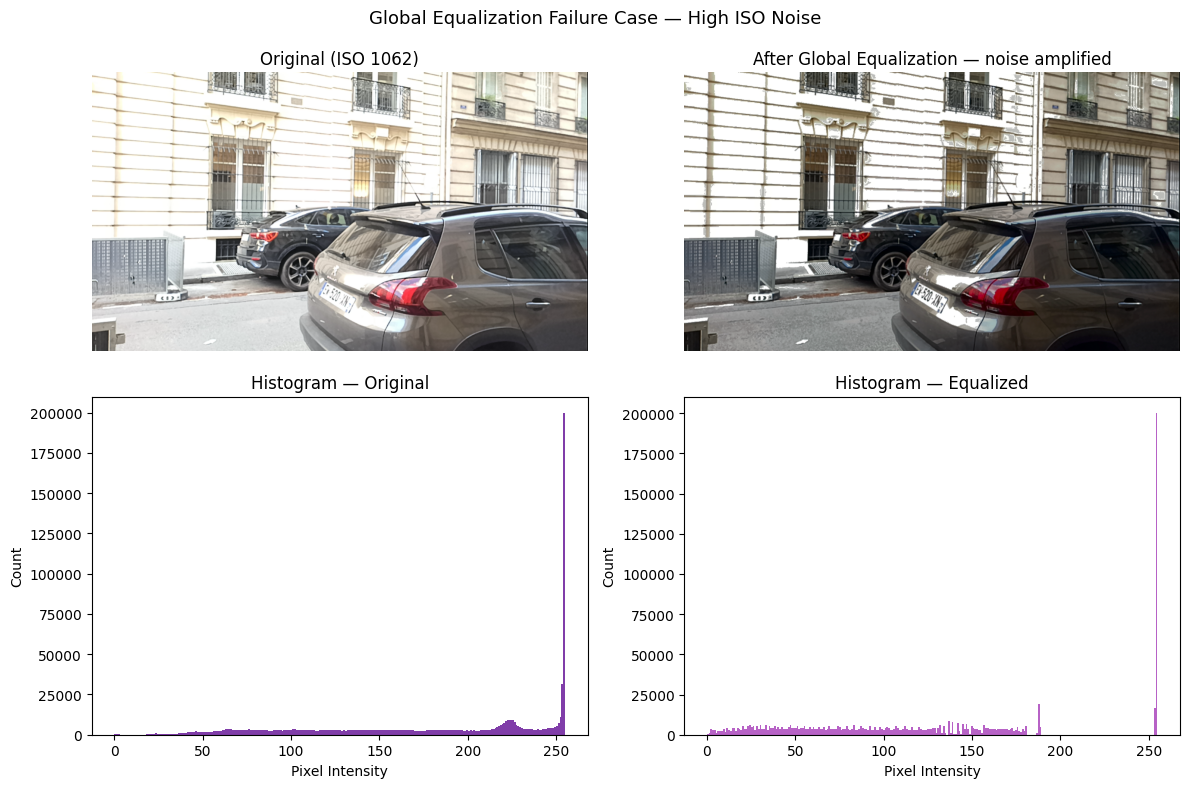

In [8]:
orig  = img_noisy
fixed = equalize_lab(img_noisy)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(orig);  axes[0, 0].set_title("Original (ISO 1062)"); axes[0, 0].axis("off")
axes[0, 1].imshow(fixed); axes[0, 1].set_title("After Global Equalization — noise amplified"); axes[0, 1].axis("off")

for ax, im, t, col in zip(axes[1], [orig, fixed],
                           ["Histogram — Original", "Histogram — Equalized"],
                           ["#6A1B9A", "#AB47BC"]):
    g = gray(im)
    ax.hist(g.ravel(), bins=256, range=(0, 255), color=col, alpha=0.85)
    ax.set_xlabel("Pixel Intensity"); ax.set_ylabel("Count"); ax.set_title(t)

plt.suptitle("Global Equalization Failure Case — High ISO Noise", fontsize=13)
plt.tight_layout()
plt.show()

---
## Technique 3 — CLAHE
### Contrast Limited Adaptive Histogram Equalization

CLAHE fixes the two problems with global equalization:

**Problem 1 — Global blindness** → CLAHE divides the image into small tiles (e.g. 8×8 pixels) and applies equalization independently in each tile. Local contrast is enhanced without affecting other regions.

**Problem 2 — Noise amplification** → A *clip limit* caps how aggressively any intensity bin can be boosted. Anything above the clip is redistributed uniformly across all bins instead of being amplified.

Finally, tiles are blended with bilinear interpolation — no visible seams between tiles.

OpenCV: `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))`

**Parameters:**
- `clipLimit` — higher = more contrast, more noise. Default 2.0 is a good start.
- `tileGridSize` — smaller tiles = more local adaptation. (8,8) works for most scenes.


In [9]:
def clahe_lab(img_rgb, clip=2.0):
    lab     = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    c       = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    lab_eq  = cv2.merge([c.apply(l), a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

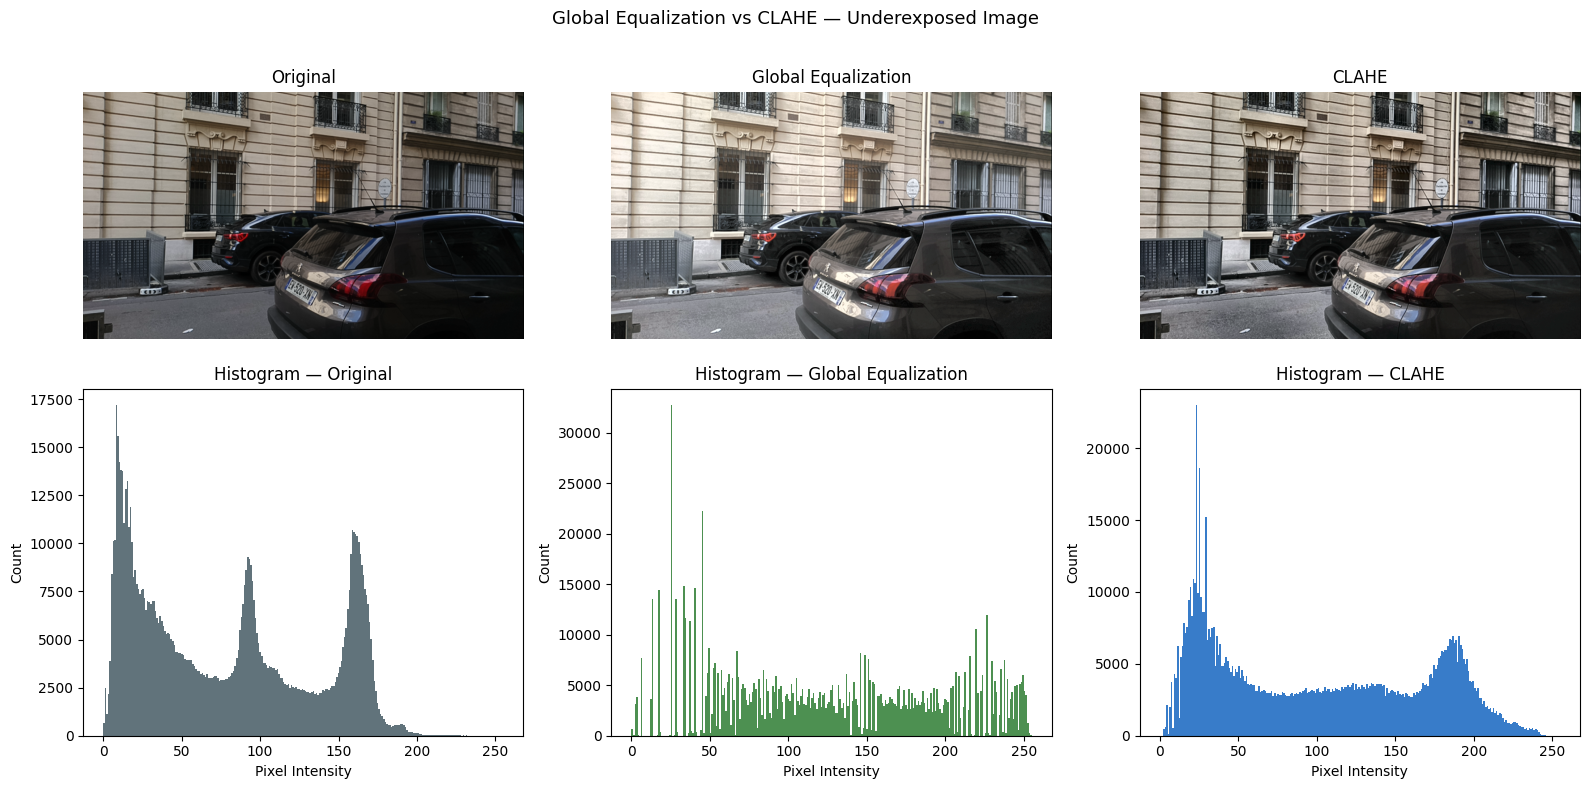

In [10]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

rgb_versions  = [img_dark, equalize_lab(img_dark), clahe_lab(img_dark)]
titles = ["Original", "Global Equalization", "CLAHE"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, (im, t) in enumerate(zip(rgb_versions, titles)):
    g = gray(im)
    axes[0, col].imshow(im); axes[0, col].set_title(t); axes[0, col].axis("off")
    axes[1, col].hist(g.ravel(), bins=256, range=(0, 255),
                      color=["#455A64", "#2E7D32", "#1565C0"][col], alpha=0.85)
    axes[1, col].set_xlabel("Pixel Intensity"); axes[1, col].set_ylabel("Count")
    axes[1, col].set_title(f"Histogram — {t}")

plt.suptitle("Global Equalization vs CLAHE — Underexposed Image", fontsize=13)
plt.tight_layout()
plt.show()

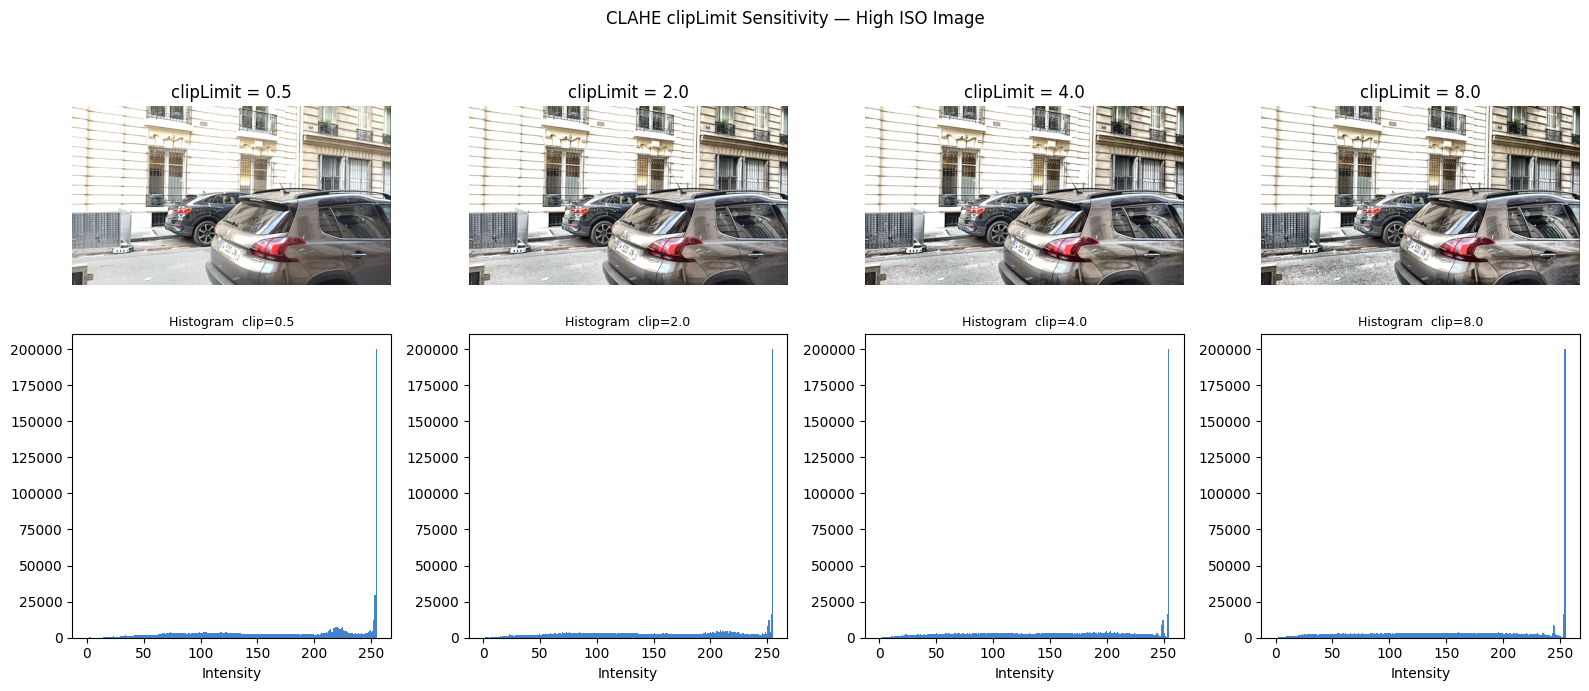

In [11]:
clips = [0.5, 2.0, 4.0, 8.0]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, clip in enumerate(clips):
    c   = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    lab = cv2.cvtColor(img_noisy, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    eq_rgb = cv2.cvtColor(cv2.merge([c.apply(l), a, b]), cv2.COLOR_LAB2RGB)
    g   = gray(eq_rgb)
    axes[0, col].imshow(eq_rgb)
    axes[0, col].set_title(f"clipLimit = {clip}"); axes[0, col].axis("off")
    axes[1, col].hist(g.ravel(), bins=256, range=(0, 255), color="#1565C0", alpha=0.8)
    axes[1, col].set_xlabel("Intensity"); axes[1, col].set_title(f"Histogram  clip={clip}", fontsize=9)

plt.suptitle("CLAHE clipLimit Sensitivity — High ISO Image", fontsize=12)
plt.tight_layout()
plt.show()

> **CLAHE is the technique you will actually use in production.**  
> It handles scenes with mixed lighting, doesn't amplify noise, and is available in every CV library.


---
## Technique 4 — Gamma Correction

A non-linear brightness adjustment. Instead of redistributing pixels statistically, it applies a power function to every pixel:

`output = (input / 255)^(1/gamma) * 255`

- `gamma > 1` → darkens the image (use when overexposed)
- `gamma < 1` → brightens the image (use when underexposed)
- `gamma = 1` → no change

Gamma < 1 brightens *gently* — it lifts shadows without blowing out highlights, because the power function has diminishing returns near 255.  
This makes it more controlled than equalization for images that are slightly off.


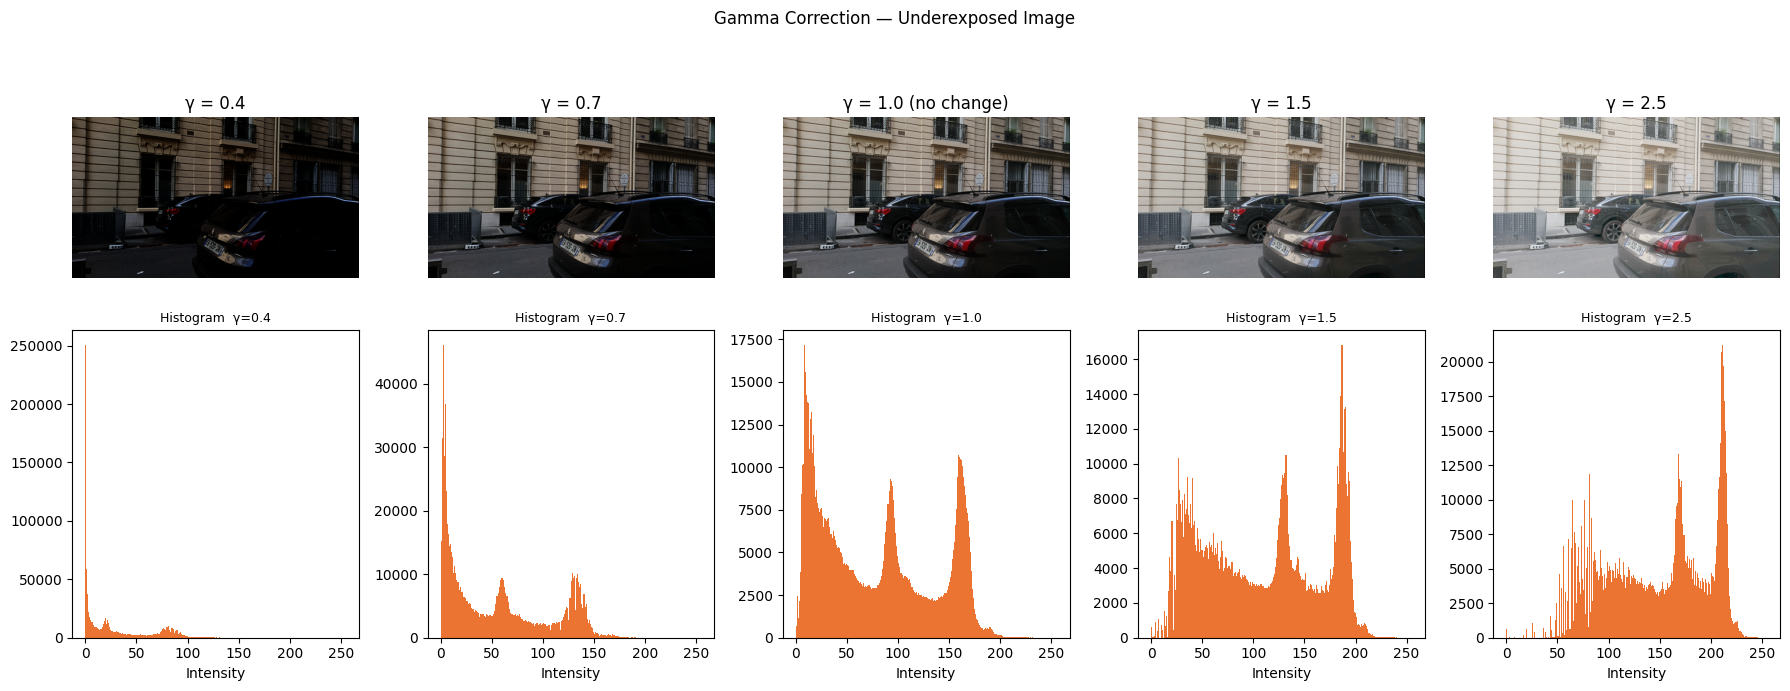

In [12]:
def apply_gamma(img, gamma):
    inv   = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img, table)  # works on RGB directly

gammas = [0.4, 0.7, 1.0, 1.5, 2.5]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for col, gamma in enumerate(gammas):
    im = apply_gamma(img_dark, gamma)
    g  = gray(im)
    axes[0, col].imshow(im)
    axes[0, col].set_title(f"γ = {gamma}" + (" (no change)" if gamma == 1.0 else ""))
    axes[0, col].axis("off")
    axes[1, col].hist(g.ravel(), bins=256, range=(0, 255), color="#E65100", alpha=0.8)
    axes[1, col].set_xlabel("Intensity"); axes[1, col].set_title(f"Histogram  γ={gamma}", fontsize=9)

plt.suptitle("Gamma Correction — Underexposed Image", fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary — All Four Techniques Side by Side


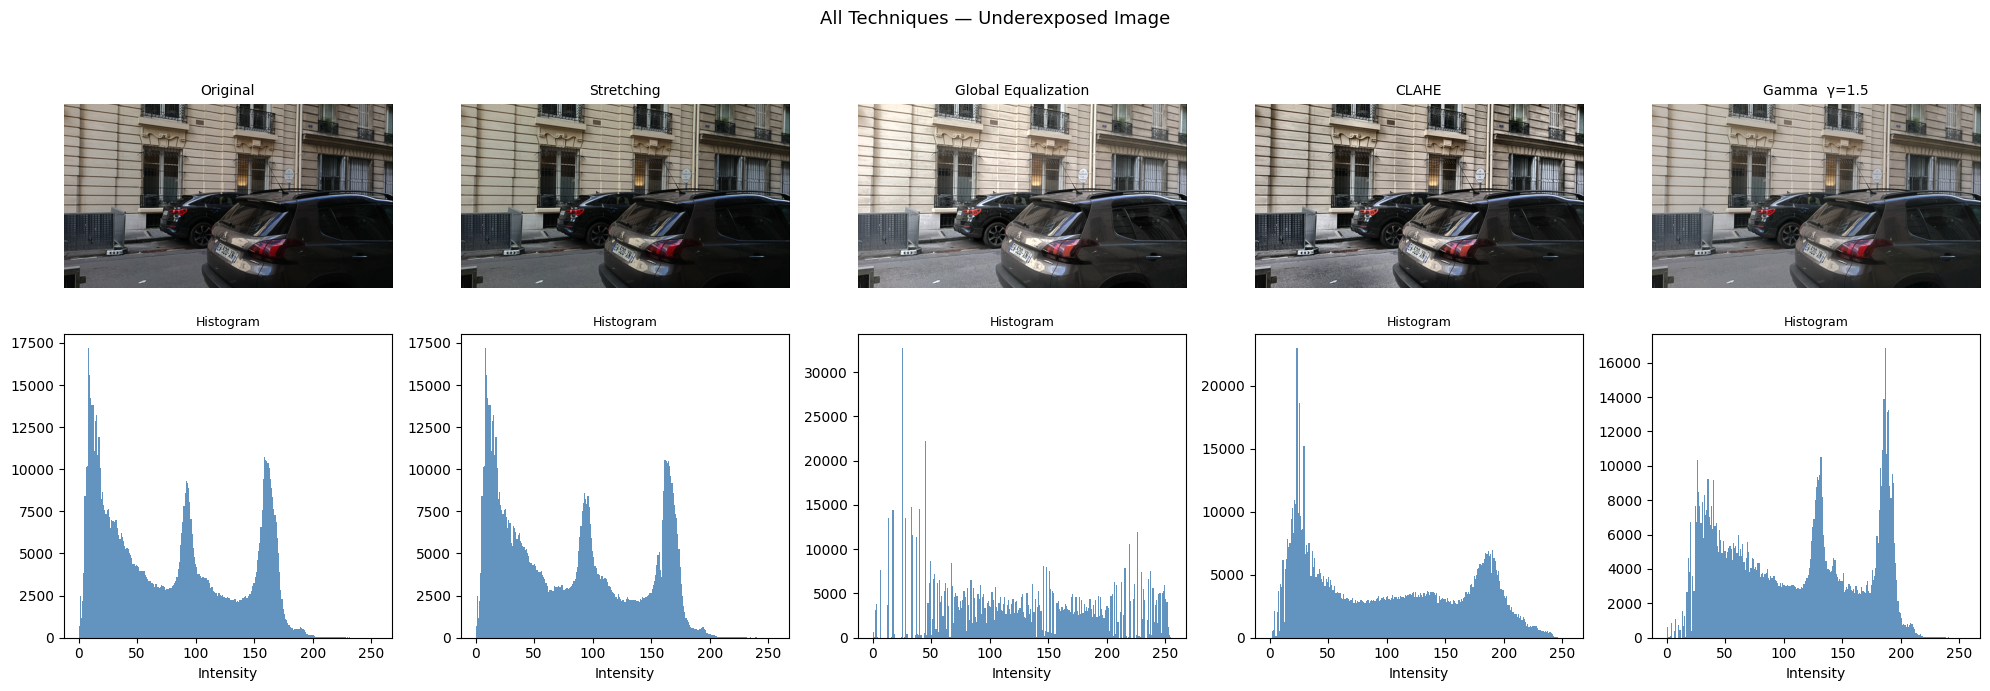

In [13]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

methods = [
    ("Original",            img_dark),
    ("Stretching",          stretch_rgb(img_dark)),
    ("Global Equalization", equalize_lab(img_dark)),
    ("CLAHE",               clahe_lab(img_dark)),
    ("Gamma  γ=1.5",        apply_gamma(img_dark, 1.5)),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for col, (title, im) in enumerate(methods):
    g = gray(im)
    axes[0, col].imshow(im); axes[0, col].set_title(title, fontsize=10); axes[0, col].axis("off")
    axes[1, col].hist(g.ravel(), bins=256, range=(0, 255), color="steelblue", alpha=0.85)
    axes[1, col].set_xlabel("Intensity"); axes[1, col].set_title("Histogram", fontsize=9)

plt.suptitle("All Techniques — Underexposed Image", fontsize=13)
plt.tight_layout()
plt.show()

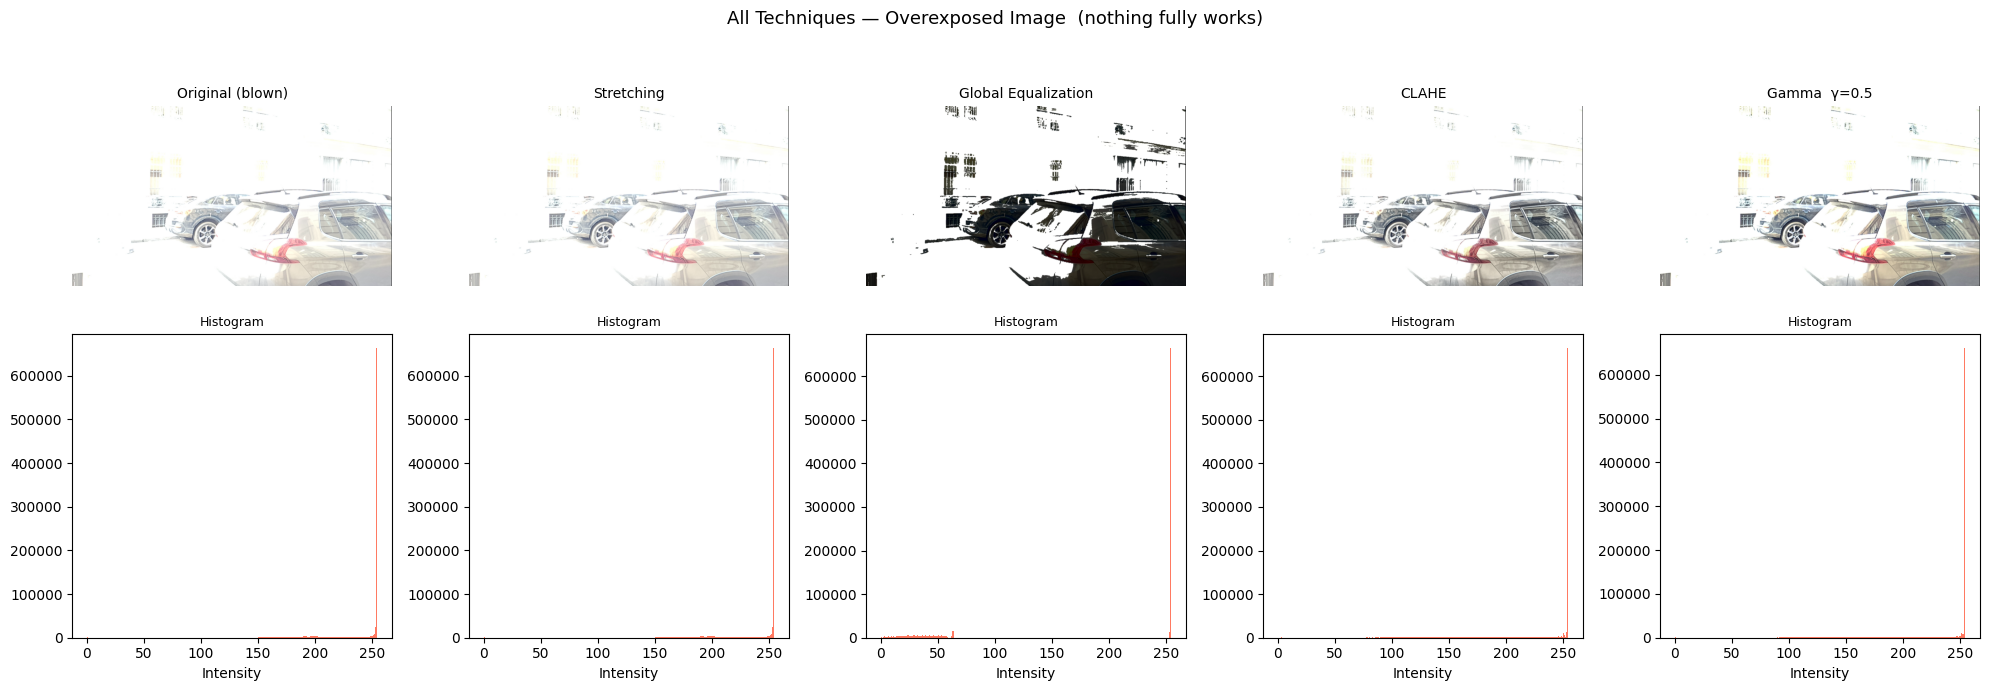

Clipped pixels in overexposed image: 662,911 (71.9%)
These pixels cannot be recovered by any post-processing technique.


In [14]:
methods_over = [
    ("Original (blown)",    img_blown),
    ("Stretching",          stretch_rgb(img_blown)),
    ("Global Equalization", equalize_lab(img_blown)),
    ("CLAHE",               clahe_lab(img_blown)),
    ("Gamma  γ=0.5",        apply_gamma(img_blown, 0.5)),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for col, (title, im) in enumerate(methods_over):
    g = gray(im)
    axes[0, col].imshow(im); axes[0, col].set_title(title, fontsize=10); axes[0, col].axis("off")
    axes[1, col].hist(g.ravel(), bins=256, range=(0, 255), color="tomato", alpha=0.85)
    axes[1, col].set_xlabel("Intensity"); axes[1, col].set_title("Histogram", fontsize=9)

plt.suptitle("All Techniques — Overexposed Image  (nothing fully works)", fontsize=13)
plt.tight_layout()
plt.show()

n_clipped = np.sum(gray(img_blown) == 255)
print(f"Clipped pixels in overexposed image: {n_clipped:,} ({100*n_clipped/gray(img_blown).size:.1f}%)")
print("These pixels cannot be recovered by any post-processing technique.")

---
## When to Use Which

| Technique | Best for | Avoid when |
|-----------|----------|------------|
| **Stretching** | Quick check, debugging | Scene has outlier bright/dark pixels |
| **Histogram Equalization** | Globally dark/flat images with no noise | Noisy images, mixed-lighting scenes |
| **CLAHE** | Almost everything in production | You need color output (use LAB version) |
| **Gamma** | Slight brightness offset, smooth correction | Large dynamic range problems |

**For color images:** always apply CLAHE on the **L channel in LAB space** — this improves contrast without distorting colors. Convert RGB → LAB, equalize L, convert back.
